In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [4]:
df = pd.read_csv("/content/train.csv")

In [5]:
df.head(10)

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278,1
1,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16 UTC,-74.016048,40.711303,-73.979268,40.782004,1
2,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00 UTC,-73.982738,40.761270,-73.991242,40.750562,2
3,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42 UTC,-73.987130,40.733143,-73.991567,40.758092,1
4,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00 UTC,-73.968095,40.768008,-73.956655,40.783762,1
5,2011-01-06 09:50:45.0000002,12.1,2011-01-06 09:50:45 UTC,-74.000964,40.731630,-73.972892,40.758233,1
6,2012-11-20 20:35:00.0000001,7.5,2012-11-20 20:35:00 UTC,-73.980002,40.751662,-73.973802,40.764842,1
7,2012-01-04 17:22:00.00000081,16.5,2012-01-04 17:22:00 UTC,-73.951300,40.774138,-73.990095,40.751048,1
8,2012-12-03 13:10:00.000000125,9.0,2012-12-03 13:10:00 UTC,-74.006462,40.726713,-73.993078,40.731628,1
9,2009-09-02 01:11:00.00000083,8.9,2009-09-02 01:11:00 UTC,-73.980658,40.733873,-73.991540,40.758138,2


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   key                50000 non-null  object 
 1   fare_amount        50000 non-null  float64
 2   pickup_datetime    50000 non-null  object 
 3   pickup_longitude   50000 non-null  float64
 4   pickup_latitude    50000 non-null  float64
 5   dropoff_longitude  50000 non-null  float64
 6   dropoff_latitude   50000 non-null  float64
 7   passenger_count    50000 non-null  int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 3.1+ MB


In [7]:
LE = LabelEncoder()

In [8]:
df['key'] = LE.fit_transform(df['key'])
df['pickup_datetime'] = LE.fit_transform(df['pickup_datetime'])

In [9]:
df.head(5)

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,3431,4.5,3408,-73.844311,40.721319,-73.841610,40.712278,1
1,7805,16.9,7748,-74.016048,40.711303,-73.979268,40.782004,1
2,20335,5.7,20152,-73.982738,40.761270,-73.991242,40.750562,2
3,25719,7.7,25488,-73.987130,40.733143,-73.991567,40.758092,1
4,9044,5.3,8973,-73.968095,40.768008,-73.956655,40.783762,1


In [10]:
df.shape

(50000, 8)

In [11]:
df.describe()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,24999.500000,11.364171,24770.967840,-72.509756,39.933759,-72.504616,39.926251,1.667840
std,14433.901067,9.685557,14295.321372,10.393860,6.224857,10.407570,6.014737,1.289195
min,0.000000,-5.000000,0.000000,-75.423848,-74.006893,-84.654241,-74.006377,0.000000
25%,12499.750000,6.000000,12388.750000,-73.992062,40.734880,-73.991152,40.734372,1.000000
50%,24999.500000,8.500000,24774.500000,-73.981840,40.752678,-73.980082,40.753372,1.000000
75%,37499.250000,12.500000,37144.250000,-73.967148,40.767360,-73.963584,40.768167,2.000000
max,49999.000000,200.000000,49554.000000,40.783472,401.083332,40.851027,43.415190,6.000000


In [12]:
df.isnull().sum()

,0
key,0
fare_amount,0
pickup_datetime,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,0
dropoff_latitude,0
passenger_count,0


In [14]:
X = df.drop(columns = 'fare_amount')
Y = df['fare_amount']

In [23]:
X.head(5)

,key,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,3431,3408,-73.844311,40.721319,-73.841610,40.712278,1
1,7805,7748,-74.016048,40.711303,-73.979268,40.782004,1
2,20335,20152,-73.982738,40.761270,-73.991242,40.750562,2
3,25719,25488,-73.987130,40.733143,-73.991567,40.758092,1
4,9044,8973,-73.968095,40.768008,-73.956655,40.783762,1


In [15]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.2,random_state = 42)

In [16]:
model = LinearRegression()

In [17]:
model.fit(X_train,Y_train)

LinearRegression()

In [18]:
y_pred = model.predict(X_test)

In [19]:
r2 = r2_score(Y_test,y_pred)
mse = mean_squared_error(Y_test,y_pred)

In [21]:
r2

0.019851281668546994

In [22]:
mse

91.12532282416224

In [31]:
input = [[9044,8973,-73.968095,40.768008,-73.956655,40.783762,1]]

In [32]:
new_fare_pred = model.predict(input)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [33]:
print("New Taxi Fare Amount is:",new_fare_pred[0])

New Taxi Fare Amount is: 9.96112150376575


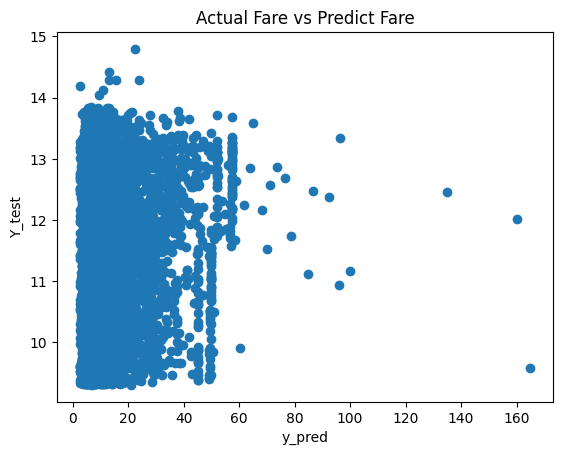

In [34]:
plt.scatter(Y_test,y_pred)
plt.xlabel("y_pred")
plt.ylabel("Y_test")
plt.title("Actual Fare vs Predict Fare")
plt.show()